In [1]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
embeddings = np.load('../Model/emb_all-MiniLM-L6-v2.npy')

description_text = pd.read_csv('../Output/london_app_doc.csv')

In [3]:
docs = description_text['description'].tolist()

In [4]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [17]:
from textwrap import fill

def _ngram_docfreq_df(docs, vectorizer, highlight_words=None):
    """
    Fit the vectorizer on docs and return a DataFrame of n-grams with document frequency.
    highlight_words : set or list
        Custom list of words/ngrams to highlight (colored differently in plots).
    """
    X = vectorizer.fit_transform(docs)
    ngrams = vectorizer.get_feature_names_out()
    doc_freq = (X > 0).sum(axis=0).A1

    if highlight_words is None:
        highlight_words = set()
    else:
        highlight_words = set(highlight_words)

    return pd.DataFrame({
        "ngram": ngrams,
        "doc_freq": doc_freq,
        "is_highlight": [ng in highlight_words for ng in ngrams]
    })


def doc_analysis_compare(
    docs,
    vectorizer_left,
    vectorizer_right,
    title_left="Vectorizer A",
    title_right="Vectorizer B",
    top_n=50,
    wrap_width=28,
    annotate=True,
    highlight_words=None,
    highlight_color="red",
    normal_color="steelblue"
):
    """
    Compare two vectorizers side-by-side by plotting the top-n most frequent n-grams.
    Custom highlight words can be passed via highlight_words.
    """
    if not isinstance(top_n, int) or top_n <= 0:
        top_n = 50

    # Compute DF tables
    df_left = _ngram_docfreq_df(docs, vectorizer_left, highlight_words)
    df_right = _ngram_docfreq_df(docs, vectorizer_right, highlight_words)

    # Sort and take top-n
    df_left_top  = df_left.sort_values("doc_freq", ascending=False).head(top_n).copy()
    df_right_top = df_right.sort_values("doc_freq", ascending=False).head(top_n).copy()

    # Wrap labels
    df_left_top["ngram_wrapped"]  = df_left_top["ngram"].apply(lambda s: fill(s, width=wrap_width))
    df_right_top["ngram_wrapped"] = df_right_top["ngram"].apply(lambda s: fill(s, width=wrap_width))

    # Colors based on highlight flag
    df_left_top["color"]  = df_left_top["is_highlight"].map(lambda x: highlight_color if x else normal_color)
    df_right_top["color"] = df_right_top["is_highlight"].map(lambda x: highlight_color if x else normal_color)

    # Adaptive height
    height = max(6, 0.22 * max(len(df_left_top), len(df_right_top)))
    common_xmax = max(df_left_top["doc_freq"].max(), df_right_top["doc_freq"].max())

    fig, axes = plt.subplots(1, 2, figsize=(18, height), sharex=True)

    # ----- Left panel -----
    ax = axes[0]
    ax.barh(df_left_top["ngram_wrapped"], df_left_top["doc_freq"], color=df_left_top["color"])
    ax.invert_yaxis()
    ax.set_xlim(0, common_xmax * 1.08)
    ax.set_title(title_left, fontsize=14, fontweight="bold", pad=10)
    ax.set_xlabel("Number of Documents", fontsize=10, fontweight="bold")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    if annotate:
        offset = max(1, int(0.01 * common_xmax))
        for y, v in enumerate(df_left_top["doc_freq"]):
            ax.text(v + offset, y, f"{int(v)}", va="center", fontsize=9)

    # ----- Right panel -----
    ax = axes[1]
    ax.barh(df_right_top["ngram_wrapped"], df_right_top["doc_freq"], color=df_right_top["color"])
    ax.invert_yaxis()
    ax.set_xlim(0, common_xmax * 1.08)
    ax.set_title(title_right, fontsize=14, fontweight="bold", pad=10)
    ax.set_xlabel("Number of Documents", fontsize=10, fontweight="bold")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    if annotate:
        offset = max(1, int(0.01 * common_xmax))
        for y, v in enumerate(df_right_top["doc_freq"]):
            ax.text(v + offset, y, f"{int(v)}", va="center", fontsize=8)

    # Global title
    fig.suptitle(
        f"Top {top_n} Most Frequent n-grams — Side-by-Side Comparison",
        fontsize=16, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.show()

    print("Left vocabulary size:", len(df_left["ngram"]))
    print("Right vocabulary size:", len(df_right["ngram"]))

    return df_left_top, df_right_top

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [26]:
stop_words_ = ['of', 'and', 'to', 'with', 'the', 'at', 'into', 'from', 'in', 'for', 'as', 'on', 'front', 'part', 'side', 'together']

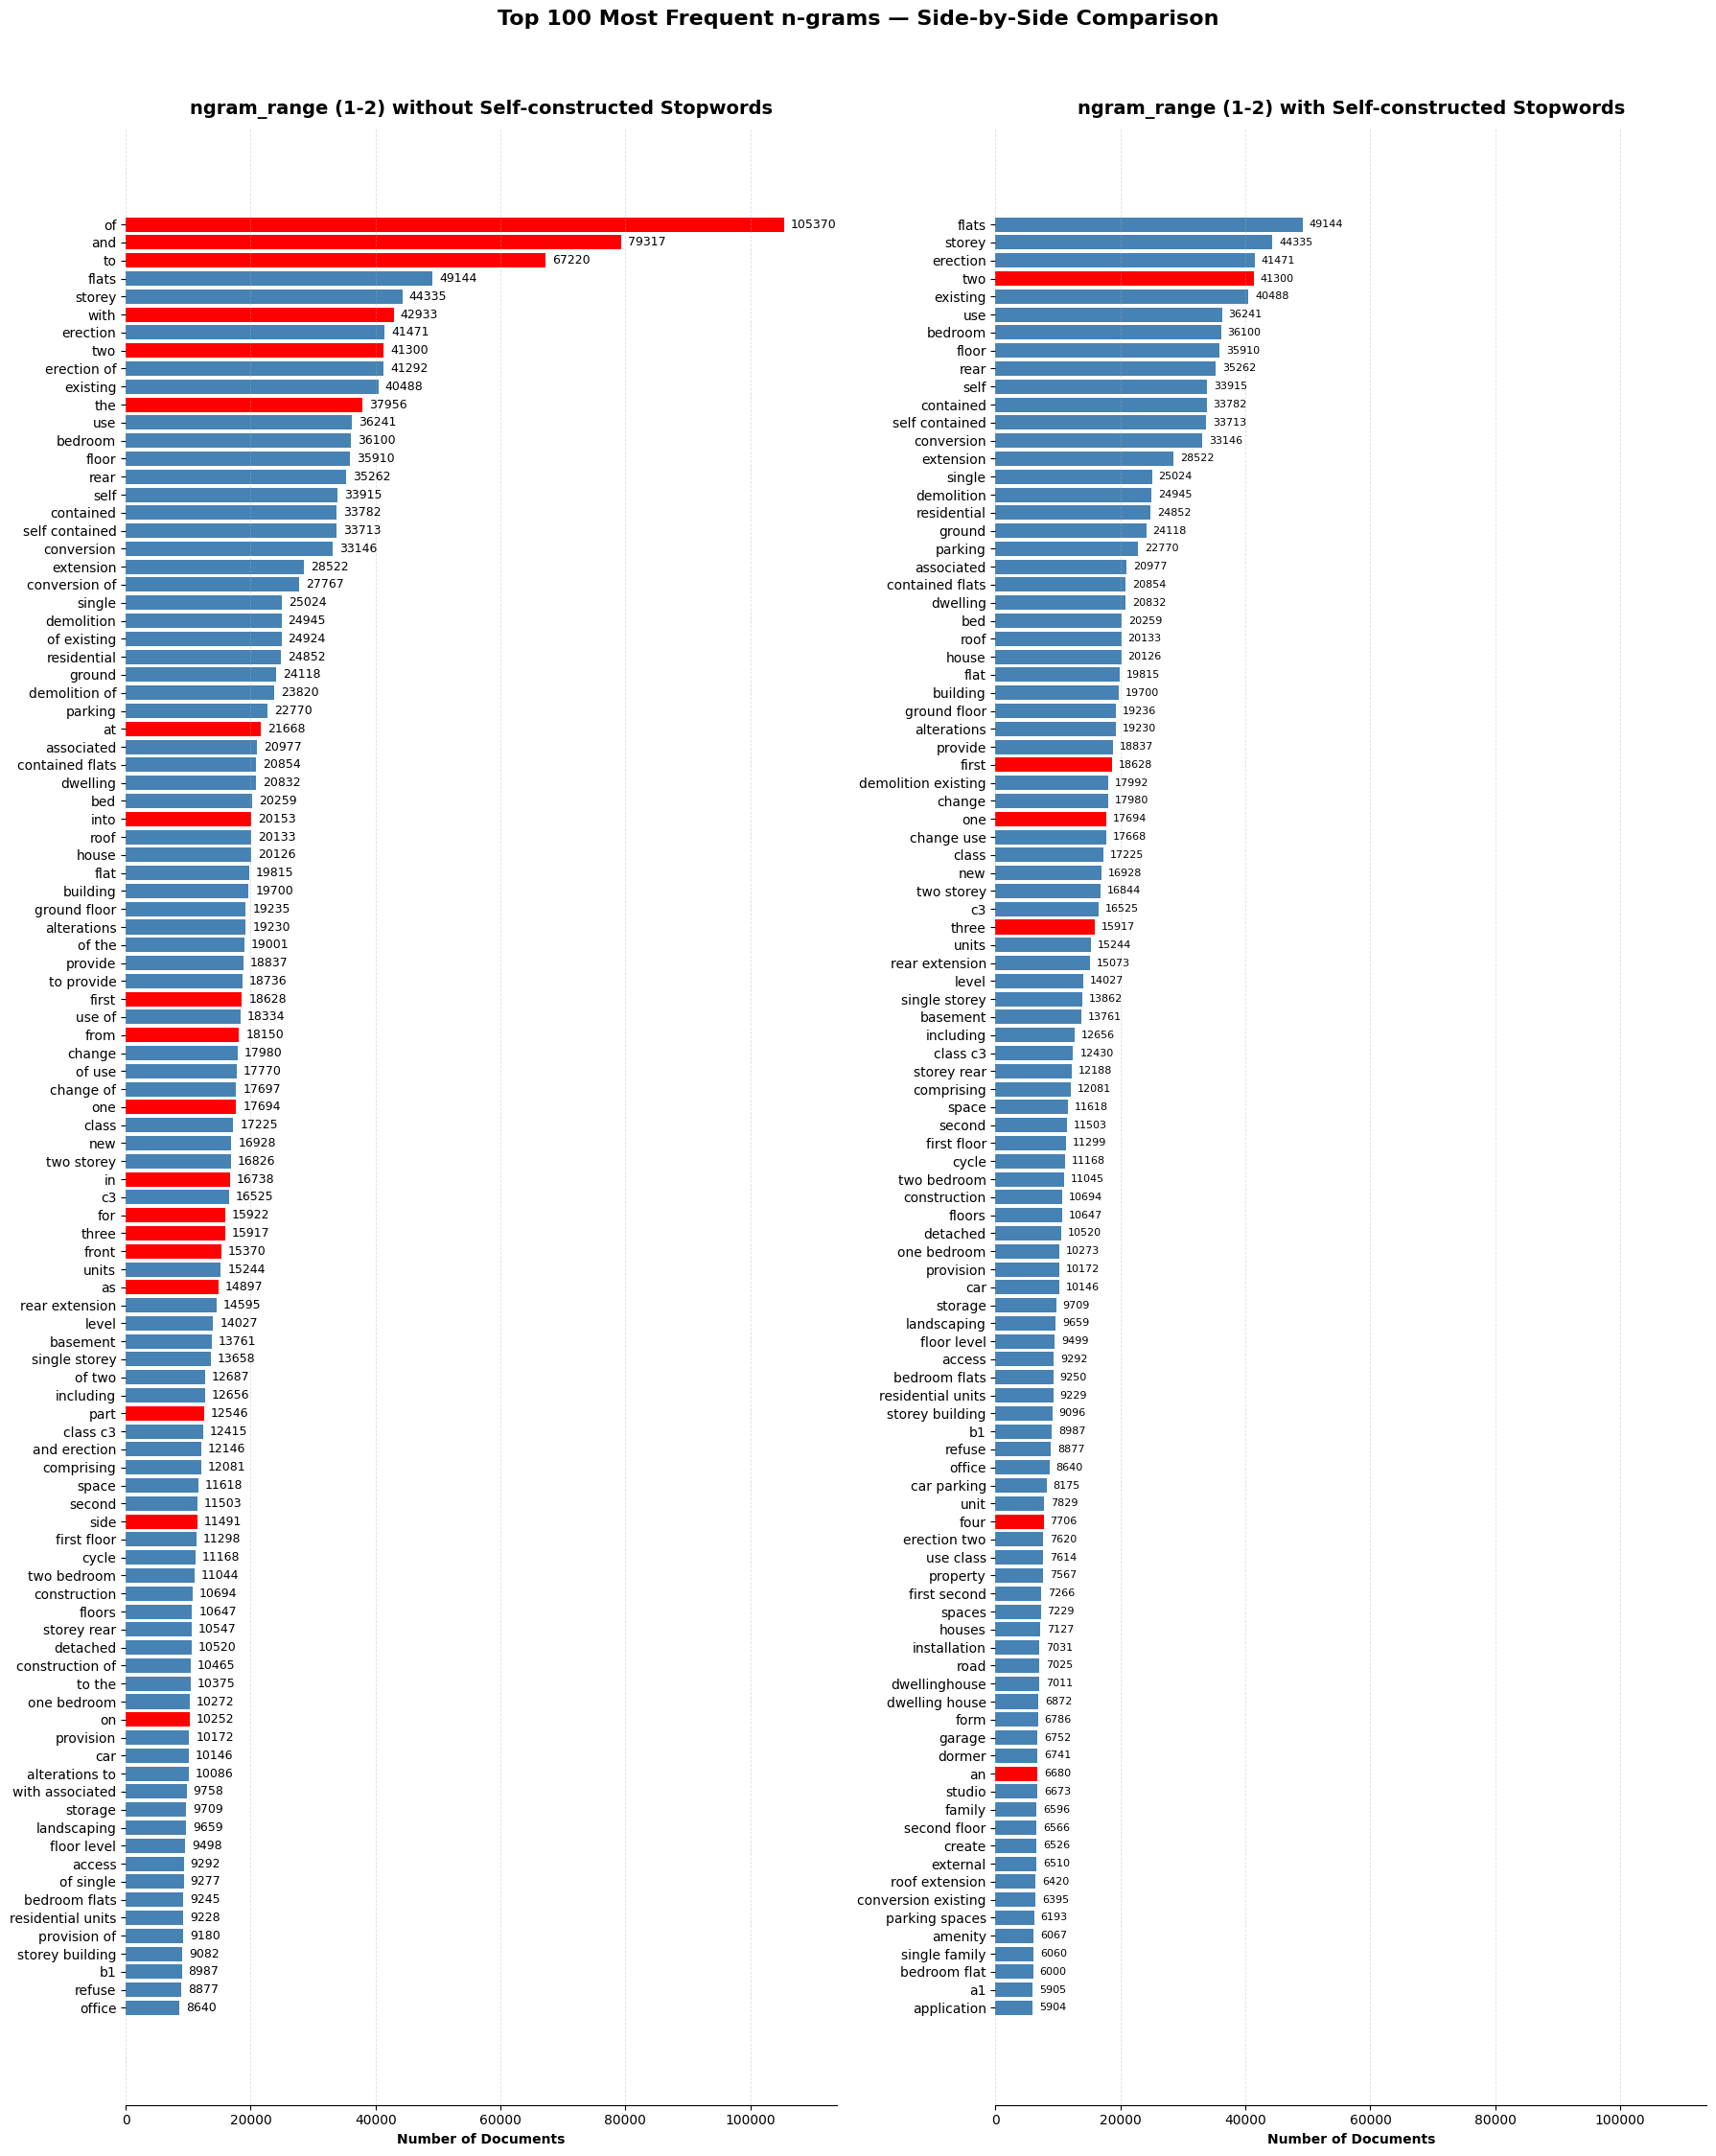

Left vocabulary size: 197786
Right vocabulary size: 228396


(                  ngram  doc_freq  is_highlight    ngram_wrapped      color
 132735               of    105370          True               of        red
 47007               and     79317          True              and        red
 181635               to     67220          True               to        red
 95168             flats     49144         False            flats  steelblue
 173733           storey     44335         False           storey  steelblue
 ...                 ...       ...           ...              ...        ...
 152222     provision of      9180         False     provision of  steelblue
 173868  storey building      9082         False  storey building  steelblue
 57262                b1      8987         False               b1  steelblue
 156428           refuse      8877         False           refuse  steelblue
 137090           office      8640         False           office  steelblue
 
 [100 rows x 5 columns],
                 ngram  doc_freq  is_highlight  n

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

vec_a = CountVectorizer(ngram_range=(1,2))
vec_b = CountVectorizer(stop_words=stop_words_,ngram_range=(1,2))

doc_analysis_compare(
    docs,
    vec_a, vec_b,
    title_left="ngram_range (1-2) without Self-constructed Stopwords",
    title_right="ngram_range (1-2) with Self-constructed Stopwords",
    top_n=100,
    highlight_words=ENGLISH_STOP_WORDS,
    highlight_color="red",
    normal_color="steelblue"
)

In [32]:
stop_words_ = stop_words + ['an']

In [33]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    min_samples=10,
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=stop_words_,
    ngram_range=(1,2)  
)

In [ ]:
import openai
from bertopic.representation import OpenAI

client = openai.OpenAI(api_key="...")

prompt = """
    You are an expert in London urban planning. Based on the following keywords from London planning application texts, 
    generate a short and clear topic label that summarizes the core development type or planning action.
    If any use-class terms appear (e.g., 'Class C1', 'Class E', 'Sui Generis'), translate them into plain English
    based on their official meanings (e.g., 'Class C1' → 'hotel or guesthouse use'). 
    The label should be understandable to a general audience while remaining accurate to UK planning context.

    I have a topic that contains the following documents:
    [DOCUMENTS]

    The topic is described by the following keywords: [KEYWORDS]

    Based on the information above, extract a short topic label in the following format:
    topic: <topic label>
"""

representation_model = OpenAI(client, model="gpt-4o-mini", prompt=prompt, delay_in_seconds=10)

In [ ]:
topic_model = BERTopic(
    language="english",
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    nr_topics="auto",
    calculate_probabilities=True
)
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

In [ ]:
topic_model.save("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2_rm=gpt-4o-mini.BERTopic", save_embedding_model=True)

In [ ]:
topic_model.visualize_term_rank()

In [36]:
def compute_diversity_score(topic_model):
    """
    Compute topic diversity score as the ratio of unique keywords 
    to total keywords across all topics (excluding topic -1).
    """
    topics_ = topic_model.get_topics()
    all_words = [
        word for topic_id, words in topics_.items() if topic_id != -1
        for word, _ in words
    ]
    unique_words = set(all_words)
    return len(unique_words) / len(all_words) if all_words else 0

In [37]:
import re
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

def compute_coherence_score(
    topic_model,
    docs, 
    top_n_words = 5,
    coherence = 'c_v'
):
    """
    Compute topic cohernece score using gensim 
    across all topics (excluding topic -1).
    """

    # Tokenize documents with a clean, custom tokenizer
    def clean_tokenizer(doc):
        return re.findall(r'\b[a-zA-Z][a-zA-Z0-9\-]{2,}\b', doc.lower())

    tokenized_docs = [clean_tokenizer(doc) for doc in docs if isinstance(doc, str) and doc.strip()]

    # Build gensim Dictionary
    dictionary = Dictionary(tokenized_docs)

    # Restrict to vectorizer's vocabulary
    vectorizer = topic_model.vectorizer_model
    vocab = set(vectorizer.get_feature_names_out())

    # Extract top words from each topic, filtering out -1
    topic_words = []
    for topic_id in topic_model.get_topic_info().Topic.tolist():
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)[:top_n_words]]
        filtered = [w for w in words if w in vocab and w in dictionary.token2id]
        if filtered:
            topic_words.append(filtered)

    # Compute coherence
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence=coherence
    )

    return coherence_model.get_coherence()

In [38]:
from collections import Counter

def topic_model_analysis(topic_model, docs):
    """
    Analyze the BERTopic model:
    - Reports number of outliers (topic -1)
    - Computes topic diversity score
    - Computes topic cohernece score
    - Prints topic summary table
    """
    # Get topic assignment info for each document
    df_info = topic_model.get_document_info(docs)
    
    # Outlier analysis
    total_docs = len(df_info)
    num_outliers = (df_info['Topic'] == -1).sum()
    outlier_ratio = num_outliers / total_docs

    print(f"Total documents: {total_docs}\n")
    print(f"Documents assigned to topic -1: {num_outliers} ({outlier_ratio:.2%})\n")

    # Topic diversity score
    diversity_score = compute_diversity_score(topic_model)
    print(f"Topic Diversity Score: {diversity_score:.4f}\n")

    coherence_score = compute_coherence_score(topic_model, docs)
    print(f"Topic Coherence Score: {coherence_score:.4f}\n")

    # Topic summary
    print("Topic Summary:")
    print(topic_model.get_topic_info())

In [ ]:
topic_model_analysis(topic_model, docs)

In [39]:
print(topic_model.get_topic_info())

      Topic  Count                                               Name  \
0        -1  48749  -1_Residential Conversion and Redevelopment Pr...   
1         0   2796  0_Conversion of Maisonettes into Self-Containe...   
2         1   1957  1_Conversion of residential properties with re...   
3         2   1954  2_Mansard Roof Extensions for Additional Resid...   
4         3   1000  3_Residential Conversion and Extension for Mul...   
...     ...    ...                                                ...   
1170   1169     10  1169_Residential Conversion and Extension for ...   
1171   1170     10  1170_Conversion of Property into Multiple Flat...   
1172   1171     10  1171_Residential Development with Flats and Co...   
1173   1172     10  1172_Conversion and Extension of Residential F...   
1174   1173     10  1173_Residential Redevelopment of Multi-Storey...   

                                         Representation  \
0     [Residential Conversion and Redevelopment Proj...   
1    

In [43]:
# Reduce embeddings to 2D
reduced_embeddings = UMAP(n_neighbors=10, n_components=2,
                          min_dist=0.0, metric='cosine', random_state=42).fit_transform(embeddings)

topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings,
                                hide_document_hover=True, hide_annotations=True)

In [ ]:
description_text_copy = pd.read_csv('../Output/london_app_doc.csv')

In [ ]:
description_text_copy['topic'] = topics
description_text_copy['probabilities'] = probs.tolist()

In [ ]:
description_text_copy.to_csv("../Output/NLP Output/feature_extraction_nt_auto.csv", index=False)

In [40]:
topic_info = topic_model.get_topic_info()

topic_info.to_csv("../Output/NLP Output/topic_info_rm_gpt4omini.csv", index=False)